In [2]:
import os
for v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'
# then numpy / xso / ssh imports BELOW this line

In [3]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

sys.path.insert(0, os.path.abspath('results/'))

In [3]:
import numpy as np, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']     # base seasonal shape
spec = ssh.allometry('maranon_ward')
GRZ, IVO = {'KsZ': 0.23, 'sigma_log': 0.2}, {'GrazingRouter': {'gge': 0.31}}
SK = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': -1e-2}

FN_SCALE = np.linspace(0.4, 2.2, 7)        # bottom-up: multiplier on F_N(t)
R_F      = np.linspace(0.0, 0.6, 7)        # top-down: fish rate
combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn'] * fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                solver_kwargs=SK),) for fs, rf in combos]

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan)
def on_result(item, done, n):
    i, j = divmod(item['index'], len(R_F))
    if item['ok']: MCS[i, j] = item['result'].get('mcs_med', np.nan)
run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None, on_result=on_result,
                   tally_flags=['has_nan'], label='fig5')
meanFN = base['fn'].mean() * FN_SCALE
print('cells done:', int(np.isfinite(MCS).sum()), '/', MCS.size)

--- run_parallel_tasks: 49 tasks, 7 workers (fig5) ---
   1/49 fig5 | err=0 has_nan=0 | 0.3m ETA 16.1m
   2/49 fig5 | err=0 has_nan=0 | 0.3m ETA 8.2m
   3/49 fig5 | err=0 has_nan=0 | 0.3m ETA 5.3m
   4/49 fig5 | err=0 has_nan=0 | 0.3m ETA 3.9m
   5/49 fig5 | err=0 has_nan=0 | 0.3m ETA 3.1m
   6/49 fig5 | err=0 has_nan=0 | 0.4m ETA 2.5m
   7/49 fig5 | err=0 has_nan=0 | 0.4m ETA 2.1m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=5290 on P[16] = -0.0129. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


   8/49 fig5 | err=0 has_nan=1 | 0.4m ETA 2.2m
   9/49 fig5 | err=0 has_nan=1 | 0.5m ETA 2.3m
  10/49 fig5 | err=0 has_nan=1 | 0.5m ETA 2.1m
  11/49 fig5 | err=0 has_nan=1 | 0.6m ETA 2.0m
  12/49 fig5 | err=0 has_nan=1 | 0.6m ETA 1.8m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1.392e+04 on P[28] = -0.0148. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  13/49 fig5 | err=0 has_nan=1 | 0.6m ETA 1.7m
  14/49 fig5 | err=0 has_nan=2 | 0.6m ETA 1.5m
  15/49 fig5 | err=0 has_nan=2 | 0.6m ETA 1.5m


...

  45/49 fig5 | err=0 has_nan=22 | 1.6m ETA 0.1m
  46/49 fig5 | err=0 has_nan=22 | 1.7m ETA 0.1m
  47/49 fig5 | err=0 has_nan=22 | 1.7m ETA 0.1m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=7332 on Z[1] = -0.0123. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  48/49 fig5 | err=0 has_nan=23 | 1.7m ETA 0.0m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1.292e+04 on P[19] = -0.0134. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  49/49 fig5 | err=0 has_nan=24 | 1.8m ETA 0.0m
--- fig5 done: 49/49 ok, 0 errored, has_nan=24 | 1.8m ---
cells done: 25 / 49


In [5]:
import warnings, numpy as np, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks
warnings.filterwarnings('ignore', message='Instability event')        # quiet the solver spam

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ, IVO = {'KsZ': 0.23, 'sigma_log': 0.2}, {'GrazingRouter': {'gge': 0.31}}
SK = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': -3e-2}  # looser floor

FN_SCALE = np.linspace(0.4, 1.7, 7)        # mean F_N ~1.1-4.6 (realistic; skips the high-supply blow-up zone)
R_F      = np.linspace(0.0, 0.6, 7)
combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn'] * fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                solver_kwargs=SK),) for fs, rf in combos]

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan); CONV = MCS.copy()
def on_result(item, done, n):
    i, j = divmod(item['index'], len(R_F))
    if item['ok']:
        m = item['result']; MCS[i, j] = m.get('mcs_med', np.nan); CONV[i, j] = m.get('mcs_conv', np.nan)
run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None, on_result=on_result,
                   tally_flags=['has_nan'], label='fig5')
meanFN = base['fn'].mean() * FN_SCALE
print('filled:', int(np.isfinite(MCS).sum()), '/', MCS.size,
      '| converged (|conv-1|<0.3):', int((np.abs(CONV - 1) < 0.3).sum()))

--- run_parallel_tasks: 49 tasks, 7 workers (fig5) ---
   1/49 fig5 | err=0 has_nan=0 | 0.3m ETA 13.1m
   2/49 fig5 | err=0 has_nan=0 | 0.3m ETA 6.6m
   3/49 fig5 | err=0 has_nan=0 | 0.3m ETA 4.4m
   4/49 fig5 | err=0 has_nan=0 | 0.3m ETA 3.2m
   5/49 fig5 | err=0 has_nan=0 | 0.3m ETA 2.6m
   6/49 fig5 | err=0 has_nan=0 | 0.3m ETA 2.1m
   7/49 fig5 | err=0 has_nan=0 | 0.3m ETA 1.8m
   8/49 fig5 | err=0 has_nan=0 | 0.4m ETA 2.3m
   9/49 fig5 | err=0 has_nan=0 | 0.5m ETA 2.2m
  10/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.9m
  11/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.8m
  12/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.6m
  13/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.4m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1639 on P[15] = -0.0527. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  14/49 fig5 | err=0 has_nan=1 | 0.6m ETA 1.4m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3561 on P[15] = -0.0359. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  15/49 fig5 | err=0 has_nan=1 | 0.6m ETA 1.3m
  16/49 fig5 | err=0 has_nan=2 | 0.6m ETA 1.2m


...

  44/49 fig5 | err=0 has_nan=15 | 1.6m ETA 0.2m
  45/49 fig5 | err=0 has_nan=16 | 1.6m ETA 0.1m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2086 on P[0] = -0.0309. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  46/49 fig5 | err=0 has_nan=17 | 1.6m ETA 0.1m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=4911 on P[18] = -0.0673. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  47/49 fig5 | err=0 has_nan=18 | 1.7m ETA 0.1m
  48/49 fig5 | err=0 has_nan=18 | 1.7m ETA 0.0m
  49/49 fig5 | err=0 has_nan=18 | 1.8m ETA 0.0m
--- fig5 done: 49/49 ok, 0 errored, has_nan=18 | 1.8m ---
filled: 31 / 49 | converged (|conv-1|<0.3): 30


NameError: name 'meanFN' is not defined

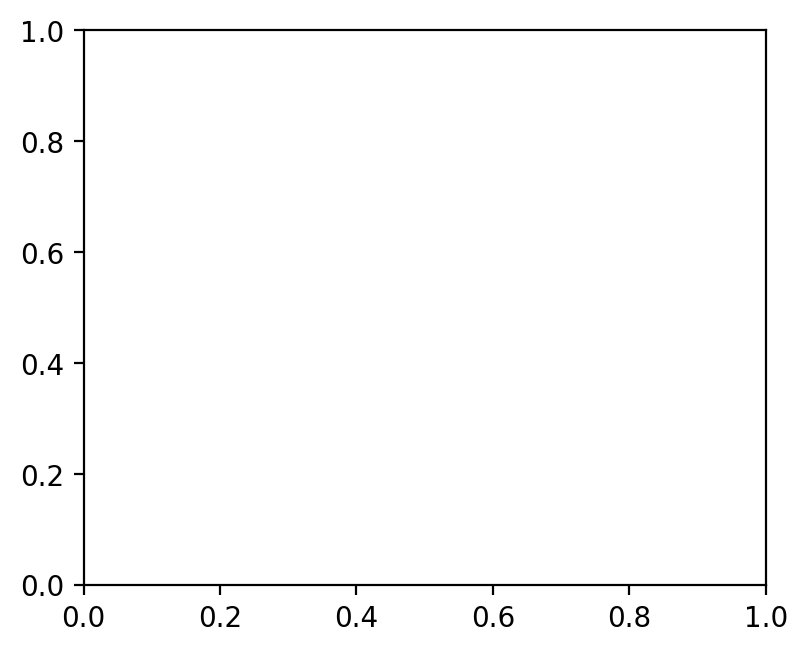

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4.4, 3.6))
pc = ax.pcolormesh(R_F, meanFN, MCS, shading='nearest', cmap='viridis')
cs = ax.contour(R_F, meanFN, MCS, levels=[2, 3, 5, 8, 12, 20], colors='white', linewidths=0.6)
ax.clabel(cs, fontsize=6, fmt='%g')
ax.plot(0.4, base['fn'].mean(), 'o', ms=9, color='#2E86AB', mec='white', label='pre+rec')
ax.plot(0.0, ssh.build_forcings(['post'])['post']['fn'].mean(), 'o', ms=9,
        color='#E07A5F', mec='white', label='post')
ax.set_xlabel('fish rate  r$_F$'); ax.set_ylabel('mean F$_N$  (mmol N m$^{-2}$ d$^{-1}$)')
fig.colorbar(pc, label='mean cell size (µm)')
ax.legend(fontsize=7, frameon=False); fig.tight_layout(); plt.show()

# Let's diagnose what is causing this:

In [7]:
clim, r = ssh.run_one(spec, {**base, 'fn': base['fn']*1.7}, fish_rate=0.0,
                      years=20, spinup=2, mP=0.0015, m_Z=0.1,
                      grazing=GRZ, iv_overrides=IVO,
                      solver_kwargs=SK, return_traj=True)
# look at the last ~365 d before NaN
t = r['t']; ok = ~np.isnan(r['sumP']); t_end = t[ok][-1]
mask = (t >= t_end - 365) & ok
print('crash time (d):', t_end, '  N_min:', np.nanmin(r['N'][mask]),
      '  Z>200 peak:', np.nanmax(r['Z200'][mask]),
      '  minP floor:', np.nanmin(r['minP'][mask]),
      '  sumP peak:', np.nanmax(r['sumP'][mask]))

crash time (d): 7299.999999999999   N_min: 4.748295227268713   Z>200 peak: 0.24331038294059887   minP floor: 0.0   sumP peak: 0.8139728458175906


In [ ]:
import warnings, time, numpy as np, seasonal_scan_harness as ssh
warnings.filterwarnings('ignore', message='Instability event')

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}
TRIP = dict(construct=spec, forcing={**base, 'fn': base['fn'] * 0.617},
            fish_rate=0.6, years=20, spinup=2,
            mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO, return_traj=True)

def _try(label, sk):
    t0 = time.perf_counter()
    clim, r = ssh.run_one(**TRIP, solver_kwargs=sk)
    dt = time.perf_counter() - t0
    t = r['t']; sp = r['sumP']; ok = ~np.isnan(sp)
    last_ok = t[ok][-1] if ok.any() else np.nan
    print(f"{label:20s} | wall {dt:5.1f}s | last finite t={last_ok:7.1f} d "
          f"({last_ok/365:5.2f} yr) | has_nan={clim['has_nan']} | "
          f"minP={np.nanmin(r['minP']):+.2e}  minZ={np.nanmin(r['minZ']):+.2e} | "
          f"sumP last={sp[ok][-1] if ok.any() else np.nan:.3f}")
    return clim, r

c_rk, r_rk = _try('RK45 (default)',  {'instability_neg_threshold': -1e-3})
c_bdf, r_bdf = _try('BDF, rtol=1e-4', {'method': 'BDF', 'rtol': 1e-4, 'atol': 1e-6,
                                        'instability_neg_threshold': -1e-3})
c_bdf2, r_bdf2 = _try('BDF, tight',   {'method': 'BDF', 'rtol': 1e-6, 'atol': 1e-9,
                                        'instability_neg_threshold': -1e-3})

In [9]:
import warnings, numpy as np, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks

# Capture the trip warning text instead of silencing it
TRIPS = []
def _trip_capturing_warner(message, category, filename, lineno, file=None, line=None):
    msg = str(message)
    if 'Instability event' in msg:
        TRIPS.append(msg)
warnings.showwarning = _trip_capturing_warner

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ, IVO = {'KsZ': 0.23, 'sigma_log': 0.2}, {'GrazingRouter': {'gge': 0.31}}
SK = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': -3e-2}

FN_SCALE = np.linspace(0.4, 1.7, 7)
R_F      = np.linspace(0.0, 0.6, 7)
combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn'] * fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                solver_kwargs=SK),) for fs, rf in combos]

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan); CONV = MCS.copy(); TRIPLOC = {}
trip_log = []   # (fs, rf, trip_msg_or_None)
def on_result(item, done, n):
    k = item['index']
    i, j = divmod(k, len(R_F))
    fs, rf = combos[k]
    if item['ok']:
        m = item['result']
        MCS[i, j]  = m.get('mcs_med', np.nan)
        CONV[i, j] = m.get('mcs_conv', np.nan)
        if m.get('has_nan'):
            # `TRIPS` is appended to in arrival order, not submission order, so we tag this
            # cell as tripped without claiming a specific message-text match
            TRIPLOC[(i, j)] = (float(fs), float(rf), float(m.get('nan_frac', np.nan)))
            trip_log.append((float(fs), float(rf), m.get('nan_frac', np.nan)))

run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None, on_result=on_result,
                   tally_flags=['has_nan'], label='fig5')

# Diagnostic summary
trip_cells = sorted(TRIPLOC.items(), key=lambda kv: (kv[1][0], kv[1][1]))
print(f"\nTrips: {len(trip_cells)} / {MCS.size}")
for (i, j), (fs, rf, frac) in trip_cells:
    print(f"  cell (i={i}, j={j}) | F_N×{fs:.3f} (mean {base['fn'].mean()*fs:.2f}) "
          f"| r_F={rf:.2f} | nan_frac={frac:.2f}")
print(f"\nRaw trip messages captured ({len(TRIPS)}):")
for m in TRIPS[:10]:
    # extract the "P[15] = -0.0527" / "Z[19] = ..." style locator
    import re
    loc = re.search(r'on\s+([PZ])\[(\d+)\]\s*=\s*([\-\d\.e]+)', m)
    t   = re.search(r't=([\d\.e\+\-]+)', m)
    print(f"  t={t.group(1) if t else '?':>10s}  class={loc.group(1)+'['+loc.group(2)+']' if loc else '?':>8s}  value={loc.group(3) if loc else '?'}")

--- run_parallel_tasks: 49 tasks, 7 workers (fig5) ---
   1/49 fig5 | err=0 has_nan=0 | 0.3m ETA 13.0m
   2/49 fig5 | err=0 has_nan=0 | 0.3m ETA 6.5m
   3/49 fig5 | err=0 has_nan=0 | 0.3m ETA 4.3m
   4/49 fig5 | err=0 has_nan=0 | 0.3m ETA 3.2m
   5/49 fig5 | err=0 has_nan=0 | 0.3m ETA 2.5m
   6/49 fig5 | err=0 has_nan=0 | 0.3m ETA 2.0m
   7/49 fig5 | err=0 has_nan=0 | 0.3m ETA 1.7m
   8/49 fig5 | err=0 has_nan=0 | 0.4m ETA 2.3m
   9/49 fig5 | err=0 has_nan=0 | 0.5m ETA 2.2m
  10/49 fig5 | err=0 has_nan=0 | 0.5m ETA 2.1m
  11/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.9m
  12/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.7m
  13/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.5m
  14/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.4m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1639 on P[15] = -0.0544. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  15/49 fig5 | err=0 has_nan=1 | 0.6m ETA 1.3m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2786 on P[15] = -0.0349. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  16/49 fig5 | err=0 has_nan=2 | 0.6m ETA 1.2m


...

  44/49 fig5 | err=0 has_nan=18 | 1.4m ETA 0.2m
  45/49 fig5 | err=0 has_nan=19 | 1.4m ETA 0.1m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2760 on Z[19] = -0.03. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  46/49 fig5 | err=0 has_nan=20 | 1.4m ETA 0.1m
  47/49 fig5 | err=0 has_nan=20 | 1.5m ETA 0.1m
  48/49 fig5 | err=0 has_nan=20 | 1.5m ETA 0.0m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=7100 on P[18] = -0.05. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  49/49 fig5 | err=0 has_nan=21 | 1.5m ETA 0.0m
--- fig5 done: 49/49 ok, 0 errored, has_nan=21 | 1.5m ---

Trips: 21 / 49
  cell (i=2, j=3) | F_N×0.833 (mean 2.56) | r_F=0.30 | nan_frac=1.00
  cell (i=2, j=5) | F_N×0.833 (mean 2.56) | r_F=0.50 | nan_frac=1.00
  cell (i=2, j=6) | F_N×0.833 (mean 2.56) | r_F=0.60 | nan_frac=0.84
  cell (i=3, j=4) | F_N×1.050 (mean 3.23) | r_F=0.40 | nan_frac=1.00
  cell (i=3, j=6) | F_N×1.050 (mean 3.23) | r_F=0.60 | nan_frac=0.88
  cell (i=4, j=1) | F_N×1.267 (mean 3.89) | r_F=0.10 | nan_frac=1.00
  cell (i=4, j=2) | F_N×1.267 (mean 3.89) | r_F=0.20 | nan_frac=0.49
  cell (i=4, j=3) | F_N×1.267 (mean 3.89) | r_F=0.30 | nan_frac=0.14
  cell (i=4, j=4) | F_N×1.267 (mean 3.89) | r_F=0.40 | nan_frac=0.88
  cell (i=4, j=5) | F_N×1.267 (mean 3.89) | r_F=0.50 | nan_frac=1.00
  cell (i=5, j=1) | F_N×1.483 (mean 4.56) | r_F=0.10 | nan_frac=0.95
  cell (i=5, j=2) | F_N×1.483 (mean 4.56) | r_F=0.20 | nan_frac=1.00
  cell (i=5, j=3) | F_N×1.483 (mean 4.56) | r_F=0.

In [10]:
SK_NO_FLOOR = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': float('-inf')}

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan)
CONV = MCS.copy(); MINP = MCS.copy(); MINZ = MCS.copy(); CVSP = MCS.copy(); HASN = MCS.copy()

def on_result_diag(item, done, n):
    k = item['index']; i, j = divmod(k, len(R_F))
    if item['ok']:
        m = item['result']
        MCS[i,j]  = m.get('mcs_med', np.nan)
        CONV[i,j] = m.get('mcs_conv', np.nan)
        MINP[i,j] = m.get('minP', np.nan)
        MINZ[i,j] = m.get('minZ', np.nan)
        CVSP[i,j] = m.get('cv_sumP', np.nan)
        HASN[i,j] = float(bool(m.get('has_nan', False)))

tasks_nf = [(dict(**{**t[0], 'solver_kwargs': SK_NO_FLOOR}),) for t in tasks]
run_parallel_tasks(ssh._seasonal_worker, tasks_nf, processes=None,
                   on_result=on_result_diag, tally_flags=['has_nan'], label='fig5_nofloor')

# Categorise
import pandas as pd
prev_trips = set(TRIPLOC.keys())               # cells that tripped under -3e-2 floor
rows = []
for (i, j) in prev_trips:
    mp, mz, cv, cn, nan = MINP[i,j], MINZ[i,j], CVSP[i,j], CONV[i,j], HASN[i,j]
    fs, rf = combos[i*len(R_F)+j]
    # category rules
    if nan or not np.isfinite(MCS[i,j]):
        cat = '2: blew up'
    elif min(mp, mz) > -3e-2:
        cat = '1: clean (negs within current floor)'
    elif min(mp, mz) > -0.15 and abs(cn - 1) < 0.3:
        cat = '1: small scar, climatology sane'
    elif abs(cn - 1) >= 0.3 or cv > 1.0:
        cat = '3: nonconvergent / wild'
    else:
        cat = '?: needs eyeball'
    rows.append(dict(i=i, j=j, FN=fs*base['fn'].mean(), rF=rf,
                     mcs=MCS[i,j], minP=mp, minZ=mz, cv_sumP=cv, conv=cn, cat=cat))
df = pd.DataFrame(rows).sort_values(['FN', 'rF'])
print(df.to_string(index=False))
print('\nCategory counts:')
print(df['cat'].value_counts().to_string())

--- run_parallel_tasks: 49 tasks, 7 workers (fig5_nofloor) ---
   1/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 13.5m
   2/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 7.2m
   3/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 4.9m
   4/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 3.6m
   5/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 2.9m
   6/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 2.3m
   7/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 2.0m
   8/49 fig5_nofloor | err=0 has_nan=0 | 0.5m ETA 2.8m
   9/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 2.5m
  10/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 2.3m
  11/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 2.1m
  12/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 1.9m
  13/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 1.7m
  14/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 1.5m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1761 on P[18] = 1.03e+50 (plus 1 other violating entries). Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  15/49 fig5_nofloor | err=0 has_nan=1 | 0.7m ETA 1.5m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3741 on P[19] = 1.67e+50 (plus 3 other violating entries). Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  16/49 fig5_nofloor | err=0 has_nan=2 | 0.7m ETA 1.4m
  17/49 fig5_nofloor | err=0 has_nan=2 | 0.8m ETA 1.4m
  18/49 fig5_nofloor | err=0 has_nan=2 | 0.8m ETA 1.4m
  19/49 fig5_nofloor | err=0 has_nan=3 | 0.8m ETA 1.3m
  20/49 fig5_nofloor | err=0 has_nan=3 | 0.8m ETA 1.2m
  21/49 fig5_nofloor | err=0 has_nan=3 | 0.9m ETA 1.1m
  22/49 fig5_nofloor | err=0 has_nan=3 | 0.9m ETA 1.1m
  23/49 fig5_nofloor | err=0 has_nan=3 | 0.9m ETA 1.1m
  24/49 fig5_nofloor | err=0 has_nan=3 | 1.0m ETA 1.1m
  25/49 fig5_nofloor | err=0 has_nan=3 | 1.1m ETA 1.0m


...

  47/49 fig5_nofloor | err=0 has_nan=19 | 3.7m ETA 0.2m


/Users/aoop/mambaforge/envs/MS3_3/lib/python3.14/site-packages/scipy/integrate/_ivp/base.py:24: UserWarning: solve_ivp has used 640000 RHS evaluations after 63.5% of the time span — at this rate the run will use ~1.0e+06 total RHS calls. The integration may take a long time. Consider Ctrl-C and restarting with solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems). If you are already on stiff_ivp and nfev is still projecting high, the model is not classically stiff — try solver='solve_ivp' (RK45 default) instead. (This warning fires once per process.)
  return np.asarray(fun(t, y), dtype=dtype)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 1165376 RHS evaluations for 2521 output points (462/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian

  48/49 fig5_nofloor | err=0 has_nan=20 | 9.7m ETA 0.2m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 1362218 RHS evaluations for 9274 output points (147/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems, may not for oscillatory predator-prey models), or loosening tolerances via solver_kwargs={'atol': 1e-6, 'rtol': 1e-4}. (This warning fires once per process.)
  self.solver.solve(self.model, time_step)


  49/49 fig5_nofloor | err=0 has_nan=21 | 11.2m ETA 0.0m
--- fig5_nofloor done: 49/49 ok, 0 errored, has_nan=21 | 11.2m ---
 i  j       FN  rF      mcs      minP          minZ  cv_sumP     conv                                  cat
 2  3 2.561264 0.3      NaN       NaN           NaN      NaN      NaN                           2: blew up
 2  5 2.561264 0.5      NaN       NaN           NaN      NaN      NaN                           2: blew up
 2  6 2.561264 0.6      NaN       NaN           NaN      NaN      NaN                           2: blew up
 3  4 3.227192 0.4 3.417513 -0.000002 -9.968582e-13 1.059457 1.013633 1: clean (negs within current floor)
 3  6 3.227192 0.6      NaN       NaN           NaN      NaN      NaN                           2: blew up
 4  1 3.893121 0.1      NaN       NaN           NaN      NaN      NaN                           2: blew up
 4  2 3.893121 0.2      NaN       NaN           NaN      NaN      NaN                           2: blew up
 4  3 3.893121 0.3  

In [11]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, xso
import parscan_utils_extended as pue
import seasonal_scan_harness as ssh
from baseline_r0_setups import (
    model_baseline, make_baseline_input_vars, SLIM_OUTPUT_VARS,
    IVP_SOLVER_KWARGS, phyto_esd, zoo_esd,
)

# --- construct: same overrides as the seasonal Fig 4 / Fig 5 work ---
spec = ssh.allometry('maranon_ward')          # Marañón μ + Ward K_s
mu_max_arr, ks_arr = spec['mu_max'], spec['halfsat']

# --- SS operating point: pre+rec era markers, decoupled forcing ---
FN0, RF0, DE0, T0 = 2.94, 0.4, 50.0, 20.0     # T0 = T_REF -> Q10 = 1 (no T effect)

iv = make_baseline_input_vars(
    fish_rate=RF0, FN=FN0, de=DE0, T=T0,
    mu_max=mu_max_arr, halfsat=ks_arr,
    mP=0.0015, m_Z=0.1,
)
iv['Grazing']['KsZ']       = 0.23
iv['Grazing']['sigma_log'] = 0.20
iv['GrazingRouter']['gge'] = 0.31

T_END = 5000.0
time_ax = np.arange(0.0, T_END, 1.0)
setup = xso.setup(solver='solve_ivp', model=model_baseline, time=time_ax,
                  input_vars=iv, output_vars=SLIM_OUTPUT_VARS,
                  solver_kwargs=IVP_SOLVER_KWARGS)
import time as _t
t0 = _t.perf_counter()
out = pue.run_single_point(model_baseline, setup, {})
print(f"wall {_t.perf_counter()-t0:.1f} s\n")

# --- diagnostics over the last 1000 d ---
P = out['Phytoplankton__biomass'].transpose('phyto', 'time').values
Z = out['Zooplankton__biomass'].transpose('zoo',   'time').values
N = out['Nutrient__value'].values
t = out['time'].values
ok_mask = ~np.isnan(P[0])
t_last = t[ok_mask][-1]
tail = (t >  t_last - 1000) & ok_mask
last100 = (t >  t_last - 100)  & ok_mask
prev100 = (t >  t_last - 200) & (t <= t_last - 100) & ok_mask

W = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
bins = W @ P; sb = bins.sum(0)
fr = np.divide(bins, sb, out=np.full_like(bins, np.nan), where=sb > 0)
mcs   = 10 ** (np.log10(GEOM) @ fr)
sumP  = P.sum(0); sumZ = Z.sum(0)
Z200  = Z[zoo_esd > 200].sum(0); Z500 = Z[zoo_esd > 500].sum(0)

def stat(x): return np.nanmean(x[tail]), np.nanstd(x[tail])
m_mcs, s_mcs = stat(mcs); m_sP, s_sP = stat(sumP); m_sZ, s_sZ = stat(sumZ)
m_N, s_N = stat(N); m_Z200, _ = stat(Z200); m_Z500, _ = stat(Z500)
m_pico, m_nano, m_micro = [np.nanmean(fr[k, tail]) for k in (0, 1, 2)]
conv = np.nanmean(mcs[last100]) / max(np.nanmean(mcs[prev100]), 1e-12)
minP_tail = float(np.nanmin(P[:, tail])); minZ_tail = float(np.nanmin(Z[:, tail]))

print(f"Run reached t = {t_last:.0f} d (target {T_END:.0f}). "
      f"has_nan = {bool(np.isnan(P).any())}\n")
print(f"Tail mean ± SD over last 1000 d:")
print(f"  mcs        = {m_mcs:6.3f} ± {s_mcs:.3f}  µm")
print(f"  Pico/Nano/Micro fractions = {m_pico:.2f} / {m_nano:.2f} / {m_micro:.2f}")
print(f"  ΣP         = {m_sP:6.3f} ± {s_sP:.3f}  mmol N m⁻³")
print(f"  ΣZ         = {m_sZ:6.3f} ± {s_sZ:.3f}  mmol N m⁻³")
print(f"  Z>200      = {m_Z200:.4f}     Z>500 = {m_Z500:.4e}  mmol N m⁻³")
print(f"  N          = {m_N:6.3f} ± {s_N:.3f}  mmol N m⁻³")
print(f"\nPhysical-ness / convergence:")
print(f"  minP over tail = {minP_tail:+.2e}  (want ≥ 0)")
print(f"  minZ over tail = {minZ_tail:+.2e}  (want ≥ 0)")
print(f"  mcs last100 / prev100 = {conv:.4f}  (want ~1.000)")
print(f"\nObs targets at the pre+rec operating point (for comparison):")
print(f"  obs MCS (pre+rec)  ≈ 7.66 µm   |  Micro ≈ 0.42  |  Z>200 ≈ 0.057  mmol N m⁻³")

wall 2.5 s

Run reached t = 4877 d (target 5000). has_nan = True

Tail mean ± SD over last 1000 d:
  mcs        =  4.285 ± 0.167  µm
  Pico/Nano/Micro fractions = 0.47 / 0.24 / 0.30
  ΣP         =  0.650 ± 0.006  mmol N m⁻³
  ΣZ         =  0.232 ± 0.000  mmol N m⁻³
  Z>200      = 0.0255     Z>500 = 1.8050e-04  mmol N m⁻³
  N          =  0.748 ± 0.004  mmol N m⁻³

Physical-ness / convergence:
  minP over tail = +0.00e+00  (want ≥ 0)
  minZ over tail = -4.05e-05  (want ≥ 0)
  mcs last100 / prev100 = 0.9769  (want ~1.000)

Obs targets at the pre+rec operating point (for comparison):
  obs MCS (pre+rec)  ≈ 7.66 µm   |  Micro ≈ 0.42  |  Z>200 ≈ 0.057  mmol N m⁻³


In [4]:
%config InlineBackend.figure_format = 'retina'
import time as _t
import numpy as np
from xso.parscans import run_xso_parscan
import seasonal_scan_harness as ssh
from baseline_r0_setups import phyto_esd

# --- axes ---
FN_VALUES = np.linspace(0.5, 6.0, 14)            # mmol N m-2 d-1
RF_VALUES = np.linspace(0.0, 0.6, 7)
DE0, T0   = 50.0, 20.0                            # decoupled forcing (T = T_REF)

# --- construct: Marañón+Ward growth + construct-D scalars ---
spec = ssh.allometry('maranon_ward')
fixed = {
    # decoupled forcing
    'Inflow__de':             DE0,
    'Temperature__value':     T0,
    # growth (Marañón μ + Ward K_s)
    'Growth__mu_max':         spec['mu_max'],
    'Growth__halfsat':        spec['halfsat'],
    # construct-D scalars (same as Fig 4 model + seasonal scan)
    'PhytoMortality__rate':   0.0015,
    'ZooQuadMortality__rate': 0.1,
    'Grazing__KsZ':           0.23,
    'Grazing__sigma_log':     0.20,
    'GrazingRouter__gge':     0.31,
}

t0 = _t.perf_counter()
scan = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim_tight',
    param_name='Inflow__FN',         param_values=FN_VALUES,
    param_name2='FishGrazing__rate', param_values2=RF_VALUES,
    fixed_overrides=fixed,
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,
)
print(f"\nwall: {(_t.perf_counter()-t0)/60:.1f} min\n")

# --- summary: list scan variables, check shape, sanity-print MCS surface ---
print("scan variables:", list(scan.data_vars))
print("scan dims     :", dict(scan.sizes))

# Try common reduction names — `avg_tail_stats` emits scalars per cell;
# adjust the keys below if the actual variable names differ.
def _take(name):
    return scan[name].values if name in scan.data_vars else None

print("\nQuick MCS surface preview (rows = F_N ↑, cols = r_F →):")
mcs = None
for k in ('mcs', 'mcs_mean', 'MCS', 'mcs_tail'):
    v = _take(k)
    if v is not None and v.shape == (len(FN_VALUES), len(RF_VALUES)):
        mcs = v; print(f"  using '{k}'"); break

if mcs is not None:
    print('       ' + '  '.join(f'r_F={rf:.2f}' for rf in RF_VALUES))
    for i, FN in enumerate(FN_VALUES):
        row = '  '.join(f'{mcs[i,j]:7.2f}' if np.isfinite(mcs[i,j]) else '    nan'
                        for j in range(len(RF_VALUES)))
        print(f'{FN:5.2f}   {row}')
    print(f"\nMCS  min={np.nanmin(mcs):.2f}  max={np.nanmax(mcs):.2f}  µm")
    print(f"finite cells: {int(np.sum(np.isfinite(mcs)))}/{mcs.size}")
else:
    print("  → no mcs-like variable found in scan output; print data_vars + ",
          "head/tail of one variable so we can resolve names.")
    for k in list(scan.data_vars)[:6]:
        print(f"  {k}: shape={scan[k].shape}  dims={scan[k].dims}")

# Flag non-converged cells if cv_sumP / tail_has_nan / similar are present
for diag in ('cv_sumP', 'cv_sumZ', 'cv_N', 'tail_has_nan'):
    if diag in scan.data_vars:
        v = scan[diag].values
        if v.dtype == bool or v.dtype == object:
            print(f"{diag}: True in {int(np.sum(v == True))}/{v.size} cells")
        else:
            print(f"{diag}: min={np.nanmin(v):.3g}  max={np.nanmax(v):.3g}  "
                  f"(>0.10 in {int(np.nansum(v > 0.10))} cells)")

PROGRESS: Completed 14/14 outer points. (Inflow__FN = 6.0).

2D Scan complete. Total Time taken: 277.95486 seconds.

wall: 4.6 min

scan variables: ['DetritusSink__sinking_value', 'Detritus__value', 'Growth__uptake_value', 'Nutrient__value', 'Phytoplankton__biomass', 'Time__time_input', 'Zooplankton__biomass', 'Core__solver_kwargs', 'Core__solver_type', 'DetritusRemin__detritus', 'DetritusRemin__k_remin', 'DetritusRemin__nutrient', 'DetritusSink__de', 'DetritusSink__detritus', 'DetritusSink__w_sink', 'Detritus__value_init', 'Detritus__value_label', 'FishGrazing__kernel_P', 'FishGrazing__kernel_Z', 'FishGrazing__phyto', 'FishGrazing__zoo', 'GrazingRouter__assimilated_consumer', 'GrazingRouter__egested_detritus', 'GrazingRouter__excreted_nutrient', 'GrazingRouter__frac_D', 'GrazingRouter__frac_export', 'GrazingRouter__grazed_phyto', 'GrazingRouter__grazed_zoo', 'Grazing__Imax', 'Grazing__consumer', 'Grazing__phyto_esd', 'Grazing__q10', 'Grazing__resource', 'Grazing__t_ref', 'Grazing__tem

Derived surfaces  (nFN x nRF):
  MCS    min=2.22  max=6.67  µm
  ΣP     min=0.31  max=0.99  mmol N m⁻³
  ΣZ     min=0.06  max=0.46  mmol N m⁻³
  Micro  min=0.03  max=0.41
  Z>200  min=0.0000  max=0.2070  mmol N m⁻³
  Z>500  min=0.0000e+00  max=8.9003e-02  mmol N m⁻³
  N      min=0.06    max=8.59    mmol N m⁻³


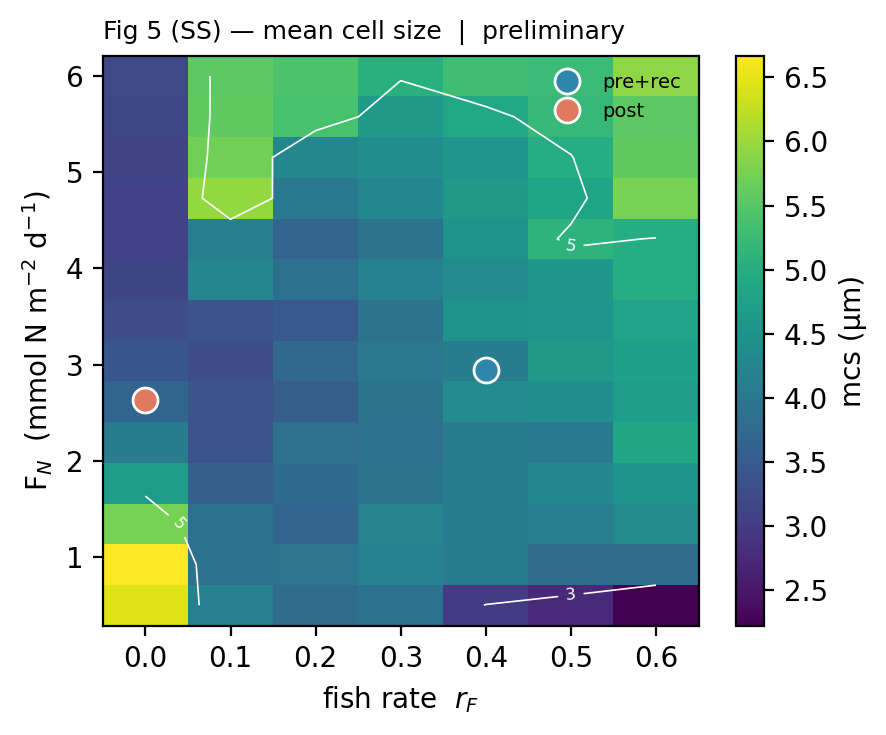


Monotonicity check:
  dMCS/dF_N > 0 in 54/91 edges (if mostly true → MCS rises with F_N)
  dMCS/dr_F > 0 in 58/84 edges (if mostly true → fish increases MCS)

Operating points (nearest grid):
  pre+rec ≈ (3.04, 0.40): MCS=4.05 µm  Micro=0.28  Z>200=0.025
  post     ≈ (2.62, 0.00): MCS=3.66 µm  Micro=0.26  Z>200=0.055
  pre/post MCS ratio: 1.11  (obs ≈ 7.66/3.28 = 2.33)


In [5]:
import numpy as np, matplotlib.pyplot as plt
import parscan_utils_extended as pue
from baseline_r0_setups import phyto_esd, zoo_esd

# --- derive MCS and the other surfaces from tail-averaged state ---
# dims in scan are (FishGrazing__rate, Inflow__FN, time=1, [phyto|zoo])
P = scan['Phytoplankton__biomass'].squeeze('time').transpose('Inflow__FN', 'FishGrazing__rate', 'phyto').values
Z = scan['Zooplankton__biomass'].squeeze('time').transpose('Inflow__FN', 'FishGrazing__rate', 'zoo').values
N = scan['Nutrient__value'].squeeze('time').transpose('Inflow__FN', 'FishGrazing__rate').values
nFN, nRF = P.shape[:2]

W    = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)

bins = np.einsum('kp,ijp->ijk', W, P)               # (nFN, nRF, 3 Sieburth bins)
sb   = bins.sum(-1)                                  # ΣP-binned per cell
fr   = np.where(sb[..., None] > 0, bins / sb[..., None], np.nan)
MCS  = 10 ** (fr @ np.log10(GEOM))                  # (nFN, nRF)
PICO, NANO, MICRO = fr[..., 0], fr[..., 1], fr[..., 2]
SUMP = P.sum(-1)
SUMZ = Z.sum(-1)
Z200 = Z[..., zoo_esd > 200].sum(-1)
Z500 = Z[..., zoo_esd > 500].sum(-1)

print("Derived surfaces  (nFN x nRF):")
print(f"  MCS    min={np.nanmin(MCS):.2f}  max={np.nanmax(MCS):.2f}  µm")
print(f"  ΣP     min={np.nanmin(SUMP):.2f}  max={np.nanmax(SUMP):.2f}  mmol N m⁻³")
print(f"  ΣZ     min={np.nanmin(SUMZ):.2f}  max={np.nanmax(SUMZ):.2f}  mmol N m⁻³")
print(f"  Micro  min={np.nanmin(MICRO):.2f}  max={np.nanmax(MICRO):.2f}")
print(f"  Z>200  min={np.nanmin(Z200):.4f}  max={np.nanmax(Z200):.4f}  mmol N m⁻³")
print(f"  Z>500  min={np.nanmin(Z500):.4e}  max={np.nanmax(Z500):.4e}  mmol N m⁻³")
print(f"  N      min={np.nanmin(N):.2f}    max={np.nanmax(N):.2f}    mmol N m⁻³")

# --- quick-look MCS pcolormesh ---
fig, ax = plt.subplots(figsize=(4.6, 3.8))
pc = ax.pcolormesh(RF_VALUES, FN_VALUES, MCS, shading='nearest', cmap='viridis')
cs = ax.contour(RF_VALUES, FN_VALUES, MCS, levels=[2, 3, 5, 8, 12, 20],
                colors='white', linewidths=0.6)
ax.clabel(cs, fontsize=6, fmt='%g')
ax.plot(0.4, 2.94, 'o', ms=9, color='#2E86AB', mec='white', label='pre+rec')
ax.plot(0.0, 2.63, 'o', ms=9, color='#E07A5F', mec='white', label='post')
ax.set_xlabel('fish rate  $r_F$')
ax.set_ylabel(r'F$_N$  (mmol N m$^{-2}$ d$^{-1}$)')
ax.set_title('Fig 5 (SS) — mean cell size  |  preliminary', fontsize=9, loc='left')
fig.colorbar(pc, label='mcs (µm)')
ax.legend(fontsize=7, frameon=False, loc='upper right')
fig.tight_layout(); plt.show()

# --- sanity-check: monotonic in F_N? in r_F? cross-term curvature? ---
def _slope(arr, axis):
    return np.diff(arr, axis=axis)
dFN = _slope(MCS, axis=0)        # MCS change as F_N rises (along rows)
drF = _slope(MCS, axis=1)        # MCS change as r_F rises (along cols)
print(f"\nMonotonicity check:")
print(f"  dMCS/dF_N > 0 in {int(np.sum(dFN > 0))}/{dFN.size} edges "
      f"(if mostly true → MCS rises with F_N)")
print(f"  dMCS/dr_F > 0 in {int(np.sum(drF > 0))}/{drF.size} edges "
      f"(if mostly true → fish increases MCS)")
print(f"\nOperating points (nearest grid):")
i_pre, j_pre = int(np.argmin(np.abs(FN_VALUES - 2.94))), int(np.argmin(np.abs(RF_VALUES - 0.4)))
i_pos, j_pos = int(np.argmin(np.abs(FN_VALUES - 2.63))), int(np.argmin(np.abs(RF_VALUES - 0.0)))
print(f"  pre+rec ≈ ({FN_VALUES[i_pre]:.2f}, {RF_VALUES[j_pre]:.2f}): "
      f"MCS={MCS[i_pre,j_pre]:.2f} µm  Micro={MICRO[i_pre,j_pre]:.2f}  "
      f"Z>200={Z200[i_pre,j_pre]:.3f}")
print(f"  post     ≈ ({FN_VALUES[i_pos]:.2f}, {RF_VALUES[j_pos]:.2f}): "
      f"MCS={MCS[i_pos,j_pos]:.2f} µm  Micro={MICRO[i_pos,j_pos]:.2f}  "
      f"Z>200={Z200[i_pos,j_pos]:.3f}")
print(f"  pre/post MCS ratio: {MCS[i_pre,j_pre]/MCS[i_pos,j_pos]:.2f}  "
      f"(obs ≈ 7.66/3.28 = 2.33)")

In [6]:
import time as _t, numpy as np
from xso.parscans import run_xso_parscan

t0 = _t.perf_counter()
scan_loose = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim',          # <-- default IVP_SOLVER_KWARGS
    param_name='Inflow__FN',         param_values=FN_VALUES,
    param_name2='FishGrazing__rate', param_values2=RF_VALUES,
    fixed_overrides=fixed,                            # reuse the same dict
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,
)
print(f"\nwall (loose): {(_t.perf_counter()-t0)/60:.1f} min   "
      f"(tight was 4.6 min)\n")

# --- side-by-side: which cells differ? ---
P_loose = scan_loose['Phytoplankton__biomass'].squeeze('time').transpose(
    'Inflow__FN', 'FishGrazing__rate', 'phyto').values
nan_loose  = scan_loose['tail_has_nan'].transpose('Inflow__FN', 'FishGrazing__rate').values
nan_tight  = scan['tail_has_nan'].transpose('Inflow__FN', 'FishGrazing__rate').values
cv_loose   = scan_loose['cv_sumP'].transpose('Inflow__FN', 'FishGrazing__rate').values
cv_tight   = scan['cv_sumP'].transpose('Inflow__FN', 'FishGrazing__rate').values

print("Trip count (tail_has_nan = True):")
print(f"  loose: {int(np.sum(nan_loose != 0))} / {nan_loose.size}")
print(f"  tight: {int(np.sum(nan_tight != 0))} / {nan_tight.size}")
print(f"\ncv_sumP (realised stability):")
print(f"  loose: max={np.nanmax(cv_loose):.4f}  >0.10 in {int(np.sum(cv_loose > 0.10))} cells")
print(f"  tight: max={np.nanmax(cv_tight):.4f}  >0.10 in {int(np.sum(cv_tight > 0.10))} cells")

# Compute MCS on both for direct comparison
W = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
def _mcs(P):
    b = np.einsum('kp,ijp->ijk', W, P); s = b.sum(-1)
    f = np.where(s[..., None] > 0, b / s[..., None], np.nan)
    return 10 ** (f @ np.log10(GEOM))

MCS_loose = _mcs(P_loose)
MCS_tight = _mcs(P)        # P from the previous (tight) scan, still in scope
diff = MCS_loose - MCS_tight
print(f"\nMCS_loose vs MCS_tight:")
print(f"  |Δ| max  = {np.nanmax(np.abs(diff)):.4f} µm")
print(f"  |Δ| mean = {np.nanmean(np.abs(diff)):.4f} µm")
print(f"  cells with |Δ| > 0.05 µm: {int(np.nansum(np.abs(diff) > 0.05))} / {diff.size}")
print(f"\nTrip cells in loose (i, j, F_N, r_F):")
trips_ij = np.argwhere(nan_loose != 0)
for i, j in trips_ij:
    print(f"  ({i:2d}, {j}) | F_N={FN_VALUES[i]:.2f}  r_F={RF_VALUES[j]:.2f}")

PROGRESS: Completed 14/14 outer points. (Inflow__FN = 6.0).

2D Scan complete. Total Time taken: 57.92632 seconds.

wall (loose): 1.0 min   (tight was 4.6 min)

Trip count (tail_has_nan = True):
  loose: 14 / 98
  tight: 0 / 98

cv_sumP (realised stability):
  loose: max=0.0215  >0.10 in 0 cells
  tight: max=0.0216  >0.10 in 0 cells

MCS_loose vs MCS_tight:
  |Δ| max  = 0.2284 µm
  |Δ| mean = 0.0074 µm
  cells with |Δ| > 0.05 µm: 2 / 98

Trip cells in loose (i, j, F_N, r_F):
  ( 6, 4) | F_N=3.04  r_F=0.40
  ( 7, 4) | F_N=3.46  r_F=0.40
  ( 7, 5) | F_N=3.46  r_F=0.50
  ( 8, 5) | F_N=3.88  r_F=0.50
  ( 8, 6) | F_N=3.88  r_F=0.60
  ( 9, 5) | F_N=4.31  r_F=0.50
  ( 9, 6) | F_N=4.31  r_F=0.60
  (10, 5) | F_N=4.73  r_F=0.50
  (10, 6) | F_N=4.73  r_F=0.60
  (11, 5) | F_N=5.15  r_F=0.50
  (11, 6) | F_N=5.15  r_F=0.60
  (12, 5) | F_N=5.58  r_F=0.50
  (12, 6) | F_N=5.58  r_F=0.60
  (13, 6) | F_N=6.00  r_F=0.60


In [7]:
import warnings, numpy as np, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks
warnings.filterwarnings('ignore', message='Instability event')
warnings.filterwarnings('ignore', message='solve_ivp')   # nfev projections

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}

# TIGHT solver_kwargs (mirror what worked at SS); default neg floor (-1e-3)
SK_TIGHT = {'method': 'RK45', 'atol': 1e-9, 'rtol': 1e-6,
            'max_step': 1.0, 'instability_neg_threshold': -1e-3}

FN_SCALE = np.linspace(0.4, 1.7, 7)
R_F      = np.linspace(0.0, 0.6, 7)
combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn'] * fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                solver_kwargs=SK_TIGHT),) for fs, rf in combos]

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan)
CONV = MCS.copy(); MINP = MCS.copy(); MINZ = MCS.copy(); CVSP = MCS.copy()
TRIPLOC_T = {}
def on_result(item, done, n):
    k = item['index']; i, j = divmod(k, len(R_F))
    if not item['ok']:
        return
    m = item['result']
    MCS[i,j]  = m.get('mcs_med', np.nan)
    CONV[i,j] = m.get('mcs_conv', np.nan)
    MINP[i,j] = m.get('minP', np.nan)
    MINZ[i,j] = m.get('minZ', np.nan)
    CVSP[i,j] = m.get('cv_sumP', np.nan)
    if m.get('has_nan'):
        fs, rf = combos[k]
        TRIPLOC_T[(i, j)] = (float(fs), float(rf), float(m.get('nan_frac', np.nan)))

run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None,
                   on_result=on_result, tally_flags=['has_nan'], label='fig5_seasonal_tight')

# --- diagnostics ---
n_trip = len(TRIPLOC_T)
n_tot  = MCS.size
print(f"\n--- TIGHT seasonal: trips {n_trip}/{n_tot}  (loose baseline was 21/49) ---\n")
if TRIPLOC_T:
    print("Trip cells still firing under tight tols:")
    for (i, j), (fs, rf, frac) in sorted(TRIPLOC_T.items(), key=lambda kv: (kv[1][0], kv[1][1])):
        print(f"  ({i:2d}, {j}) | F_N×{fs:.3f} (mean {base['fn'].mean()*fs:.2f}) "
              f"| r_F={rf:.2f} | nan_frac={frac:.2f}")
else:
    print("All cells completed without NaN-termination.")

# Stability picture of the converged cells
print(f"\ncv_sumP: max={np.nanmax(CVSP):.3f}  >0.10 in {int(np.nansum(CVSP > 0.10))} cells")
print(f"|conv-1|: max={np.nanmax(np.abs(CONV-1)):.3f}  >0.05 in {int(np.nansum(np.abs(CONV-1) > 0.05))} cells")
print(f"minP: min={np.nanmin(MINP):+.2e}  ({int(np.nansum(MINP < -1e-3))} cells < -1e-3)")
print(f"minZ: min={np.nanmin(MINZ):+.2e}  ({int(np.nansum(MINZ < -1e-3))} cells < -1e-3)")

--- run_parallel_tasks: 49 tasks, 7 workers (fig5_seasonal_tight) ---
   1/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.8m ETA 40.4m
   2/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 20.2m
   3/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 13.6m
   4/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 10.0m
   5/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 7.8m
   6/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 6.4m
   7/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 5.3m
   8/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.6m ETA 8.4m
   9/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 7.4m
  10/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 6.5m
  11/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 5.7m
  12/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 5.2m
  13/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 4.7m
  14/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.9m ETA 4.8m
  15/49 fig5_seasonal_tight | err=0 has_nan=0 | 2.4m ETA 5

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4.4, 3.6))
pc = ax.pcolormesh(R_F, meanFN, MCS, shading='nearest', cmap='viridis')
cs = ax.contour(R_F, meanFN, MCS, levels=[2, 3, 5, 8, 12, 20], colors='white', linewidths=0.6)
ax.clabel(cs, fontsize=6, fmt='%g')
ax.plot(0.4, base['fn'].mean(), 'o', ms=9, color='#2E86AB', mec='white', label='pre+rec')
ax.plot(0.0, ssh.build_forcings(['post'])['post']['fn'].mean(), 'o', ms=9,
        color='#E07A5F', mec='white', label='post')
ax.set_xlabel('fish rate  r$_F$'); ax.set_ylabel('mean F$_N$  (mmol N m$^{-2}$ d$^{-1}$)')
fig.colorbar(pc, label='mean cell size (µm)')
ax.legend(fontsize=7, frameon=False); fig.tight_layout(); plt.show()